In [522]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.optimize as sco 
import seaborn as sns

In [523]:
daily_returns = pd.read_csv(
    "data/processed/daily_returns.csv",
    index_col=0,
    parse_dates=True
)

adj_close = pd.read_csv(
    "data/processed/adj_close.csv",
    index_col=0,
    parse_dates=True
)

cov_matrix = pd.read_csv(
    "data/processed/cov_matrix.csv",
    index_col=0
)

metrics_table = pd.read_csv(
    "data/processed/metrics_table.csv",
    index_col=0
)

daily_rfr = pd.read_csv(
    "data/processed/daily_risk_free_rate.csv",
    index_col = 0
)

In [524]:
from src.metrics import portfolio_return, portfolio_volatility, sharpe_ratio, negative_sharpe

In [525]:
long_returns = daily_returns.reset_index().melt(id_vars = 'Date', value_vars = daily_returns.columns)
long_returns.columns = ['Date', 'Asset','Return']
long_returns['Date'] = pd.to_datetime(long_returns['Date'])
long_returns = long_returns.sort_values(['Asset','Date'])
daily_rfr.index = pd.to_datetime(daily_rfr.index)
long_returns = long_returns.merge(
    daily_rfr,
    left_on='Date',
    right_index= True,
    how = 'left'
)
long_returns['excess_return'] = long_returns['Return'] - long_returns['daily_rfr']

In [526]:
long_adj_close = adj_close.reset_index().melt(id_vars = 'Date', value_vars = adj_close.columns).set_index('Date')
long_adj_close.columns = ['Asset','Adj_close']
long_adj_close = long_adj_close.sort_values(['Asset','Date'])
long_adj_close['log_return'] = (
    long_adj_close.groupby('Asset')['Adj_close'].transform(
        lambda x: np.log(x).diff())
    )
long_adj_close = long_adj_close.dropna(subset = ['log_return'])
long_data = long_returns.merge(
    long_adj_close,
    on = ('Date', 'Asset'),
    how = 'inner'
)
long_data['Date'] = pd.to_datetime(long_data['Date'])

## Static Optimized Portfolio - Baseline

In [527]:
## CREATING WEIGHTS ##
weight_list = (
    0.15, #AGG
    0.00, #EEM
    0.15, #EFA
    0.15, #GLD
    0.00, #IWM
    0.10, #LQD
    0.05, #MTUM
    0.15, #QQQ
    0.00, #QUAL
    0.10, #SPY
    0.00, #TLT
    0.00, #USMV
    0.15, #VLUE
    0.00  #VNQ
)
weights = {}
for i in range(len(daily_returns.columns)):
    key = daily_returns.columns[i]
    weight = weight_list[i]
    weights[key] = weight
long_data['weights'] = long_data['Asset'].map(weights)

if sum(weight_list) != 1:
    print("Does Not Equal 1")
else:
    print('Weights Equal 1')


Weights Equal 1


In [528]:
## ESTABLISHING BASELINE PERFORMANCE FOR THE INITITAL PORTFOLIO ##

long_data['weighted_returns'] = long_data['weights'] * long_data['Return']

weighted_returns_df = pd.DataFrame(long_data.groupby('Date')['weighted_returns'].sum()).reset_index()

weighted_returns_df['rolling_return'] = weighted_returns_df['weighted_returns'].rolling(21).mean()
weighted_returns_df['rolling_vol'] =  weighted_returns_df['weighted_returns'].rolling(21).std() * np.sqrt(252)

weighted_returns_df['portfolio_value'] = (
    1 + weighted_returns_df['weighted_returns']
).cumprod()
weighted_returns_df['running_peak'] = weighted_returns_df['portfolio_value'].cummax()
weighted_returns_df['drawdown'] = (
    weighted_returns_df['portfolio_value'] / weighted_returns_df['running_peak'] - 1
)


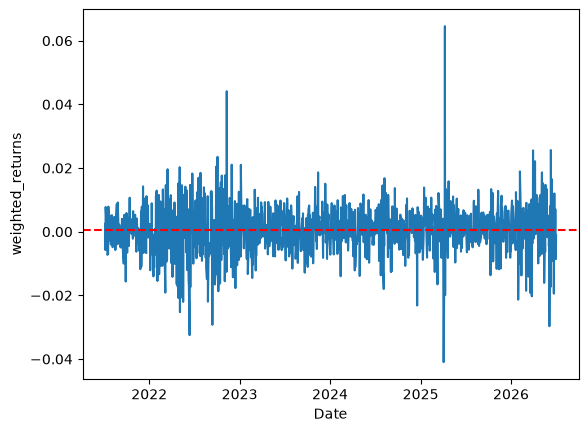

In [529]:
sns.lineplot(data = weighted_returns_df, x = 'Date', y = 'weighted_returns')
plt.axhline(y=weighted_returns_df['weighted_returns'].mean(), color='red', linestyle='--')

## Time-Based Rebalancing Strategy

In [530]:
## REBALANCING ANNUALLY BASED ON PENALIZED SHARPE RATIO ##
from src.config import portfolio_groups, asset_class_caps, asset_bounds
from src.optimization import build_constraints

In [531]:
tb_portfolio = long_data.copy()
tb_portfolio['Year'] = tb_portfolio['Date'].dt.year

In [532]:
tickers = daily_returns.columns

constraints = build_constraints(
    tickers,
    portfolio_groups,
    asset_class_caps
)

bounds = tuple(asset_bounds for _ in range(len(tickers)))

In [533]:
daily_rfr = pd.Series(tb_portfolio.groupby('Date')['daily_rfr'].mean().values)
daily_rfr

0       0.000002
1       0.000002
2       0.000002
3       0.000002
4       0.000002
          ...   
1248    0.000152
1249    0.000154
1250    0.000154
1251    0.000153
1252    0.000153
Length: 1253, dtype: float64

In [534]:
## Function for evaluating by date ## 
## Period Weights to be an asset indexed series of predetermined weights ##
## df will be a time-series of portfolio return data ## 
def annual_evaluation(start_date, end_date, period_weights, df):
    eval_data = df[df['Date'].between(start_date, end_date)].copy()

    eval_data['weights'] = eval_data['Asset'].map(period_weights)
    eval_data['weighted_returns'] = eval_data['weights'] * eval_data['Return']
    daily_rfr = pd.Series(eval_data.groupby('Date')['daily_rfr'].mean()).values

    daily_portfolio = (
        eval_data
        .groupby('Date', as_index=False)['weighted_returns']
        .sum()
        .rename(columns={'weighted_returns': 'portfolio_return'})
    )
    daily_portfolio['rf_rate'] = daily_rfr
    daily_portfolio['portfolio_value'] = (
        1 + eval_data['weighted_returns']
    ).cumprod()

    daily_portfolio['running_peak'] = daily_portfolio['portfolio_value'].cummax()

    daily_portfolio['drawdown'] = (
        daily_portfolio['portfolio_value'] / daily_portfolio['running_peak'] - 1
    )
    summary = {
        'start_date': start_date,
        'end_date': end_date,
        'period_return': daily_portfolio['portfolio_value'].iloc[-1] - 1,
        'volatility': daily_portfolio['portfolio_return'].std() * np.sqrt(252),
        'max_drawdown': daily_portfolio['drawdown'].min(),
        'avg_daily_return': daily_portfolio['portfolio_return'].mean()
    }

    return daily_portfolio, summary


In [539]:
weights_2021 = pd.Series(weight_list, index = daily_returns.columns)
port_start = tb_portfolio['Date'].iloc[0]

eval_results = []

daily_2021, summary_2021 = annual_evaluation(
    start_date = port_start,
    end_date = '2021-12-31',
    period_weights=weights_2021,
    df = tb_portfolio)

eval_results.append(summary_2021)
results_df = pd.DataFrame(eval_results)
results_df

,start_date,end_date,period_return,volatility,max_drawdown,avg_daily_return
0,2021-07-07,2021-12-31,-0.000845,0.08022,-0.003364,0.000363


In [536]:
## Creating reuseable optimization function ##

def optimizer(df, start_date, end_date):

    opt_df = df[df['Date'].between(start_date, end_date)].copy()

    rf = opt_df['daily_rfr'].mean()

    returns = (
        opt_df.pivot(index = 'Date', columns = 'Asset', values = 'Return')
        )
    returns_mean = returns.mean()
    returns_cov = returns.cov()
    initial = np.array([1/ len(returns.columns)] * len(returns.columns))
    
    optimized = sco.minimize(
    negative_sharpe,
    initial, 
    args = (returns_mean, returns_cov, rf),
    method = "SLSQP",
    bounds = bounds,
    constraints = constraints
    )

    return pd.Series(optimized.x, index = daily_returns.columns)


In [540]:

weights_2022 = optimizer(
    df = tb_portfolio, 
    start_date= port_start,
    end_date= '2022-12-31'
          )

daily_2022, summary_2022 = annual_evaluation(
    start_date = '2022-01-01',
    end_date = '2022-12-31',
    period_weights=weights_2022,
    df = tb_portfolio)

eval_results.append(summary_2022)
results_df = pd.DataFrame(eval_results)
results_df

,start_date,end_date,period_return,volatility,max_drawdown,avg_daily_return
0,2021-07-07 00:00:00,2021-12-31,-0.000845,0.080220,-0.003364,0.000363
1,2022-01-01,2022-12-31,-0.014256,0.150637,-0.018694,-0.000485


In [543]:
first_two = pd.concat([daily_2021, daily_2022])
first_two

,Date,portfolio_return,rf_rate,portfolio_value,running_peak,drawdown
0,2021-07-07,0.002462,0.000002,1.000259,1.000259,0.000000
1,2021-07-08,-0.005760,0.000002,1.000427,1.000427,0.000000
2,2021-07-09,0.007764,0.000002,0.999936,1.000427,-0.000491
3,2021-07-12,0.002485,0.000002,0.999845,1.000427,-0.000582
4,2021-07-13,-0.003601,0.000002,0.999521,1.000427,-0.000906
...,...,...,...,...,...,...
246,2022-12-23,0.002551,0.000172,0.982719,0.998974,-0.016272
247,2022-12-27,-0.001882,0.000177,0.983569,0.998974,-0.015421
248,2022-12-28,-0.008593,0.000177,0.984239,0.998974,-0.014750
249,2022-12-29,0.012082,0.000177,0.985470,0.998974,-0.013518


<Axes: xlabel='Date', ylabel='portfolio_return'>

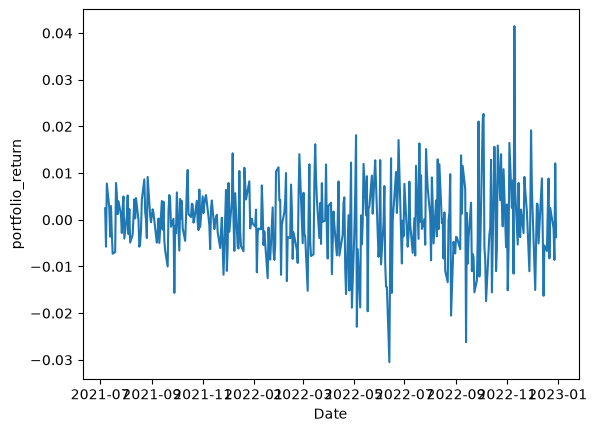

In [544]:

sns.lineplot(data = first_two, x = 'Date', y = 'portfolio_return')